#### 0. Importar librerias

In [1]:
import pandas as pd
import sklearn
import missingno as mo
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

#### 1. Cargar e inspeccionar los datos

In [2]:
df = pd.read_csv('Datos/Transformados/df_final_para_regresion.csv')

C:\Users\Uxue Duran Nuño\AppData\Local\Temp\ipykernel_17760\924406895.py:1: DtypeWarning: Columns (48,55,57,61,64,66,69,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Datos/Transformados/df_final_para_regresion.csv')


In [3]:
df.head()

,booked_at,checkin_time,checkout_time,lead_time,lenght_of_stay,checkin_month,checkin_day,adult_count,child_count,origin,...,presMin,horaPresMin,hrMedia,hrMax,horaHrMax,hrMin,horaHrMin,ciudad_y,fecha_date,cluster
0,2022-11-26 16:10:00,2023-01-01 12:00:00,2023-01-02 12:00:00,36,1,January,Sunday,1,0,channel_manager,...,983.6,17,30.0,98.0,23:59,27.0,Varias,Donosti,2023-01-01,2
1,2022-12-21 17:27:00,2023-01-01 13:09:00,2023-01-10 12:00:00,11,9,January,Sunday,1,0,channel_manager,...,983.6,17,30.0,98.0,23:59,27.0,Varias,Donosti,2023-01-01,2
2,2022-09-21 19:46:00,2023-01-01 15:00:00,2023-01-07 12:00:00,102,6,January,Sunday,2,4,channel_manager,...,983.6,17,30.0,98.0,23:59,27.0,Varias,Donosti,2023-01-01,2
3,2022-09-24 12:09:00,2023-01-01 15:00:00,2023-01-02 12:00:00,99,1,January,Sunday,2,2,channel_manager,...,983.6,17,30.0,98.0,23:59,27.0,Varias,Donosti,2023-01-01,2
4,2022-10-18 07:12:00,2023-01-01 15:00:00,2023-01-02 12:00:00,75,1,January,Sunday,4,0,channel_manager,...,983.6,17,30.0,98.0,23:59,27.0,Varias,Donosti,2023-01-01,2


In [4]:
df.columns

Index(['booked_at', 'checkin_time', 'checkout_time', 'lead_time',
       'lenght_of_stay', 'checkin_month', 'checkin_day', 'adult_count',
       'child_count', 'origin', 'travel_agency_name', 'requested_category',
       'requested_category_name', 'asset', 'asset_type', 'brand',
       'asset_opening_date', 'available_units', 'business_segment', 'rate',
       'rate_group_name', 'rate_type', 'completed_entry_forms_count',
       'all_entry_forms_completed', 'last_entry_form_completed_at',
       'returning_inhabitant', 'recurrence', 'libere_community',
       'bought_products', 'product_count', 'reservation_net_value',
       'total_adr', 'status', 'cancelled_at', 'cancellation_reason',
       'cancellation_lead_time', 'ciudad_x', 'mes_cancelacion',
       'estacion_cancelacion', 'mes_estancia', 'estacion_estancia',
       'espera_dias', 'meses_espera', 'espera_zona_roja', 'ratio_asistencia',
       'checkin_date', 'ciudad_clean', 'fecha', 'indicativo', 'nombre',
       'provincia', 'a

In [5]:
df['cluster'].unique()

array([2, 0, 1])

In [7]:
df.shape

(52150, 75)

<Axes: >

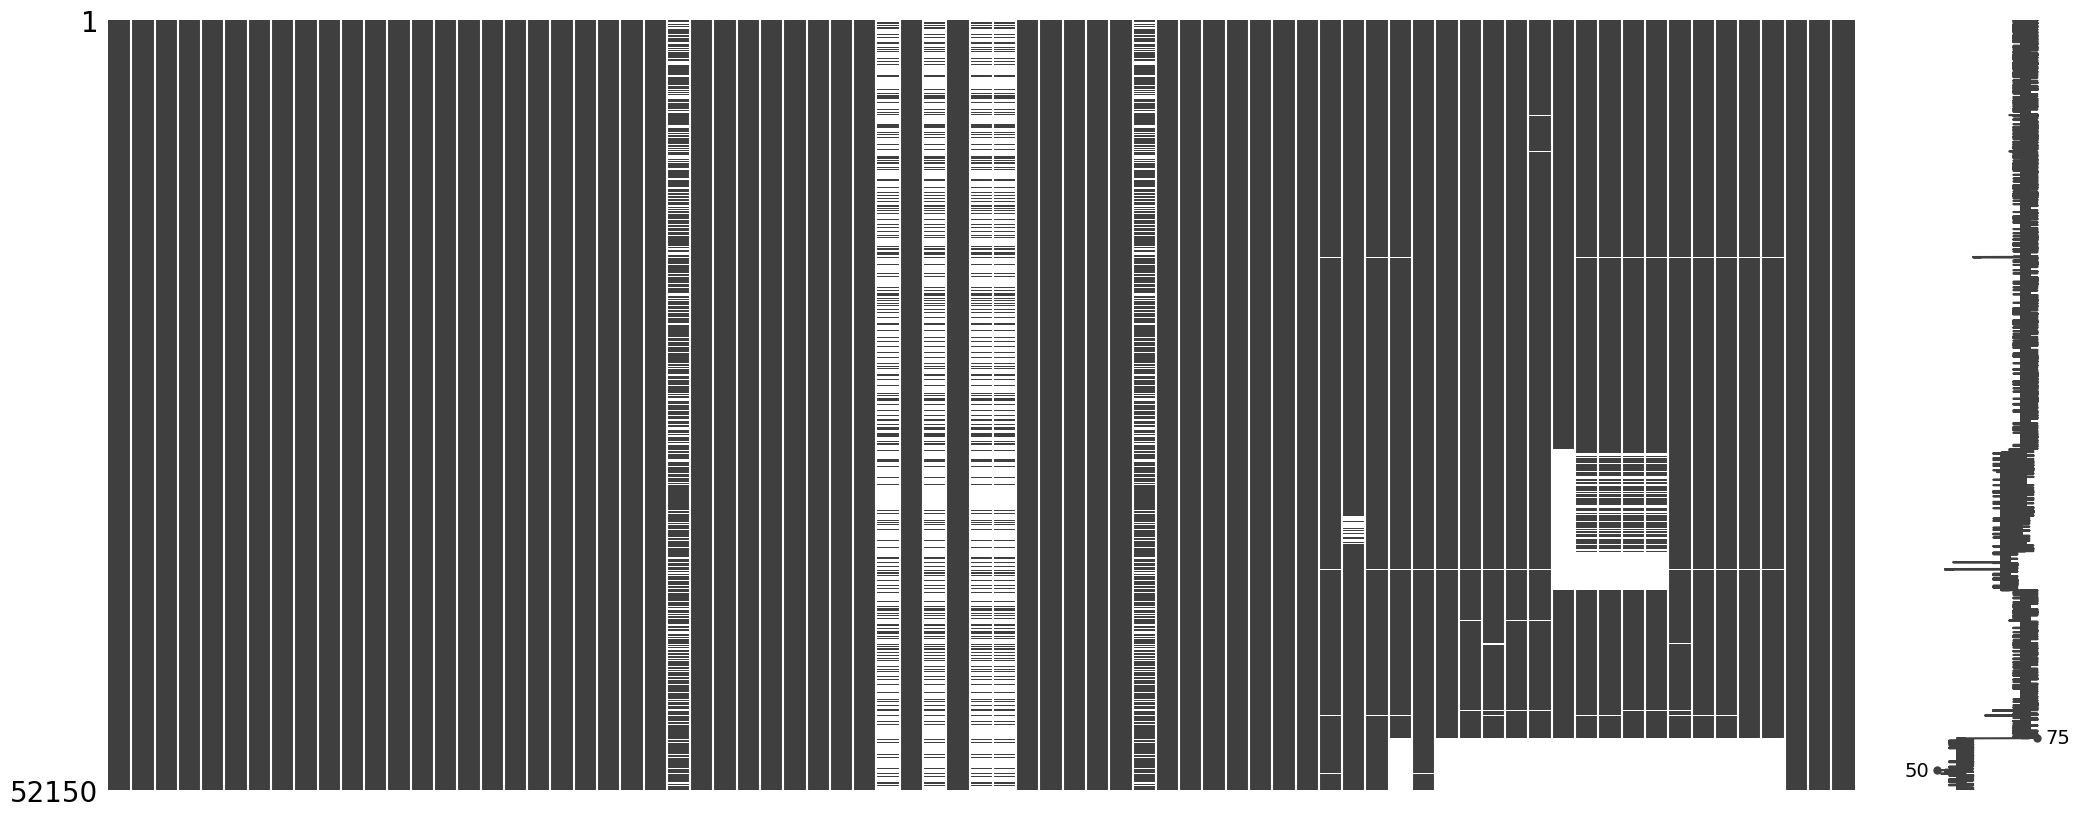

In [9]:
mo.matrix(df)

#### 3. Seleccion de variables relevantes para modelado

In [ ]:
# Criterio para la seleccion de variables para regresion:
#    1. Primero se seleccionan únicamente variables disponibles en el momento de la reserva y que, desde el punto de vista de negocio, puedan influir en la probabilidad de cancelación.
#    2. Después mirar la relacion entre cada una de ellas con el target:
#       - para las numericas con corr
#       - para las binarias media del target
#       - para las categoricas la tasa de cancelacion por grupo (si se acaba seleccionando pasar a dummies)
#    3. Entre las seleccionadas, eliminar las que tengan alta correlacion entre ellas